Epoch 0: Error=1.0811, a=0.7435, b=0.9435, c=0.8695
Epoch 500: Error=0.3691, a=0.0511, b=1.0725, c=0.6830
Epoch 1000: Error=0.3205, a=0.0615, b=1.0840, c=0.4944
Epoch 1500: Error=0.2591, a=0.1136, b=1.1087, c=0.1773
Epoch 2000: Error=0.3008, a=0.1355, b=1.1280, c=-0.2454
Epoch 2500: Error=0.2696, a=0.2068, b=1.1752, c=-0.6773

Mejores parámetros encontrados: a=0.2374, b=1.1917, c=-1.0082, d=0.0000


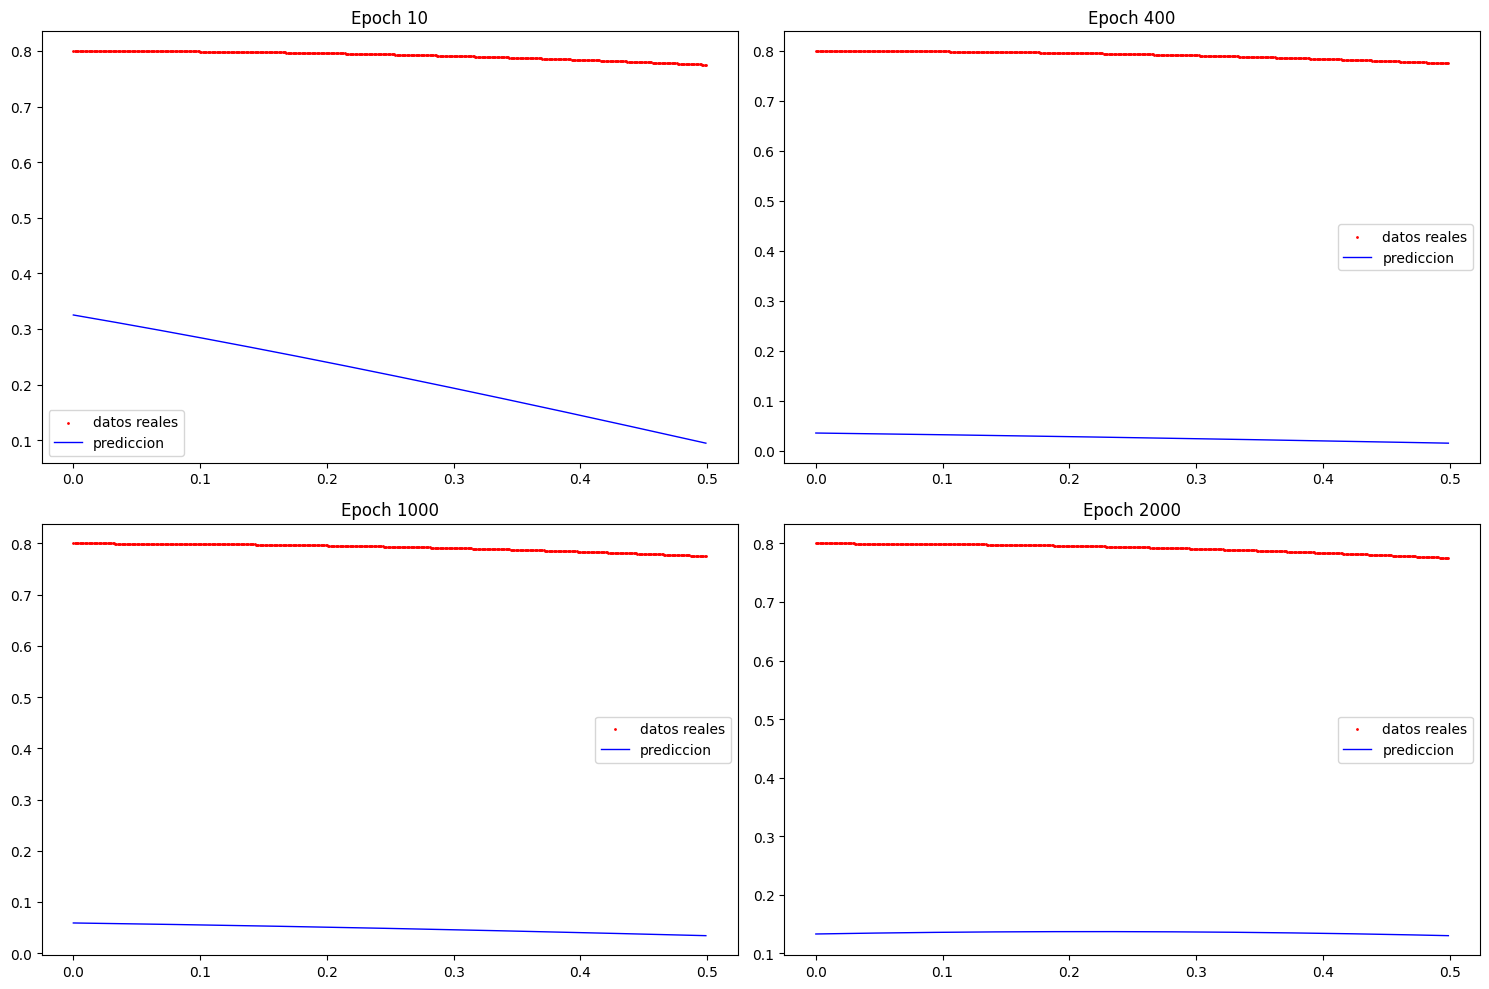

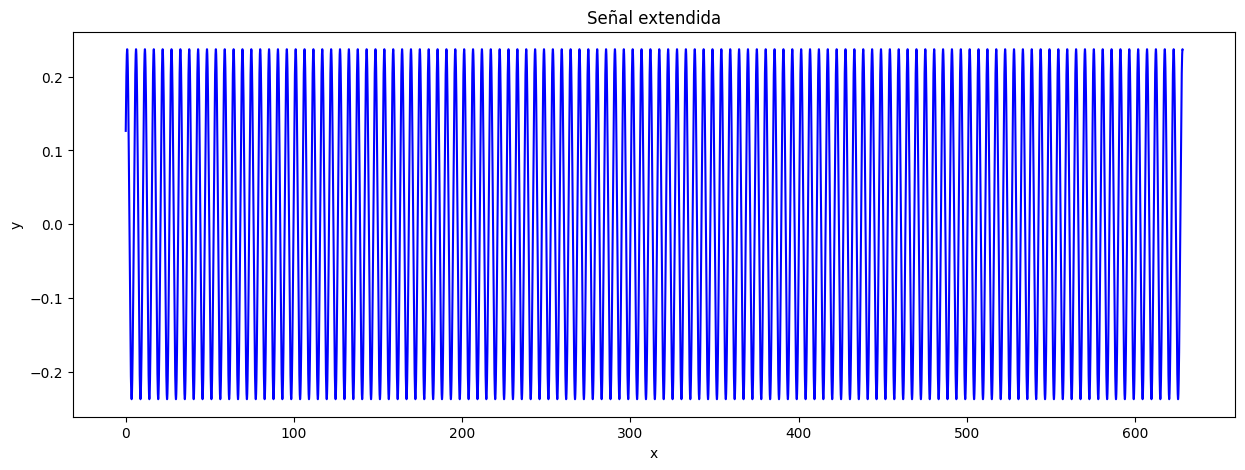

me reproduci


TypeError: OutputStream.__init__() got an unexpected keyword argument 'rate'

In [12]:
import numpy as np
import pandas as pd
import math
import random
import matplotlib.pyplot as plt
import sounddevice as sd
from IPython.display import Audio
from scipy.io.wavfile import write
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

train_data = pd.read_csv('./data1/train.csv')
x_train = train_data['x'].values
y_train = train_data['TARGET'].values

def y_predict(a, b, c, d, x):
    return a * np.cos(b * x + c) + d

def gradient_descent(x, y, epochs=3000, batch_size=100, lr=0.05, d=0):
    n = len(x)
    a = random.random()
    b = random.random()
    c = random.random()
    results = []
    for epoch in range(epochs):
        a_grad = 0
        b_grad = 0
        c_grad = 0
        total_error = 0
        for _ in range(batch_size):
            idx = int(random.uniform(0, n))
            x_i = x[idx]
            y_i = y[idx]
    
            y_pred = y_predict(a, b, c, d, x_i)
            error = (y_i - y_pred)
            total_error += error ** 2

            a_grad += -2 * error * np.cos(b * x_i + c)
            b_grad += 2 * error * a * x_i * np.sin(b * x_i + c)
            c_grad += 2 * error * a * np.sin(b * x_i + c)
        
        a -= lr * (a_grad / batch_size)
        b -= lr * (b_grad / batch_size)
        c -= lr * (c_grad / batch_size)
        
        avg_error = total_error / batch_size
        results.append([a, b, c, d, avg_error])
        
        if epoch % 500 == 0:
            print(f"Epoch {epoch}: Error={avg_error:.4f}, a={a:.4f}, b={b:.4f}, c={c:.4f}")
    
    return results

results = gradient_descent(x_train, y_train)

best_params = results[-1]
a, b, c, d, _ = best_params
print(f"\nMejores parámetros encontrados: a={a:.4f}, b={b:.4f}, c={c:.4f}, d={d:.4f}")

def plot_comparison(x, y_true, params, epoch_num, ax):
    a, b, c, d, _ = params
    y_pred = [y_predict(a, b, c, d, xi) for xi in x]
    
    ax.scatter(x, y_true, s=1, color='red', label='datos reales')
    ax.plot(x, y_pred, color='blue', linewidth=1, label='prediccion')
    ax.set_title(f'Epoch {epoch_num}')
    ax.legend()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
selected_epochs = [10, 400, 1000, 2000]

for i, epoch in enumerate(selected_epochs):
    row = i // 2
    col = i % 2
    params = results[epoch-1] 
    plot_comparison(x_train[:500], y_train[:500], params, epoch, axes[row, col])

plt.tight_layout()
plt.show()

x_min = min(x_train)
long_x = np.arange(x_min, 200 * np.pi, 0.001)
long_s = [y_predict(a, b, c, d, xi) for xi in long_x]

plt.figure(figsize=(15, 5))
plt.plot(long_x, long_s, color='blue')
plt.title('Señal extendida')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

print("me reproduci")
sd.play(long_s,rate=44100)
Audio(long_s, rate=44100)


scaled = np.int16(long_s / np.max(np.abs(long_s)) * 32767)
write('generated_signal.wav', 44100, scaled)

test_data = pd.read_csv('./data1/test.csv')
x_test = test_data['x'].values

# Predecir valores para test
y_test_pred = [y_predict(a, b, c, d, xi) for xi in x_test]

# Crear archivo de submission
submission = pd.DataFrame({
    'example_id': test_data['example_id'],
    'TARGET': y_test_pred
})

submission.to_csv('results1.csv', index=False)

In [27]:
train_df = pd.read_csv('./data2/train.csv')
test_df = pd.read_csv('./data2/test.csv')

def simplify_category(cat):
    if cat in ['Entretenimiento', 'Deportes', 'Película y Animación', 'Educación']:
        return cat
    return 'Otros'

train_df['categoria'] = train_df['categoria'].apply(simplify_category)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    return text

train_df['titulo_clean'] = train_df['titulo'].apply(clean_text)
test_df['titulo_clean'] = test_df['titulo'].apply(clean_text)
#TF-IDF
tfidf = TfidfVectorizer(max_features=50000, stop_words='english')
X_tfidf = tfidf.fit_transform(train_df['titulo_clean'])
y = train_df['categoria']

#train / test
X_train, X_val, y_train, y_val = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=10000, multi_class='multinomial')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_val)

print("Regresión Logística:")
print(classification_report(y_val, y_pred_lr))
rf = RandomForestClassifier(n_estimators=10000, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)

print("Random Forest:")
print(classification_report(y_val, y_pred_rf))
tokenizer = Tokenizer(num_words=50000)
tokenizer.fit_on_texts(train_df['titulo_clean'])

X_seq = tokenizer.texts_to_sequences(train_df['titulo_clean'])
X_pad = pad_sequences(X_seq, maxlen=20)


le = LabelEncoder()
y_encoded = le.fit_transform(train_df['categoria'])


X_train_lstm, X_val_lstm, y_train_lstm, y_val_lstm = train_test_split(
    X_pad, y_encoded, test_size=0.2, random_state=42)

#LSTM
model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=20),
    LSTM(64),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

history = model.fit(X_train_lstm, y_train_lstm, 
                    epochs=10, batch_size=64, 
                    validation_data=(X_val_lstm, y_val_lstm))

y_pred_lstm = model.predict(X_val_lstm)
y_pred_lstm = le.inverse_transform(np.argmax(y_pred_lstm, axis=1))
y_val_orig = le.inverse_transform(y_val_lstm)

print("LSTM:")
print(classification_report(y_val_orig, y_pred_lstm))
X_test_tfidf = tfidf.transform(test_df['titulo_clean'])
X_test_seq = tokenizer.texts_to_sequences(test_df['titulo_clean'])
X_test_pad = pad_sequences(X_test_seq, maxlen=20)

test_pred_lr = lr.predict(X_test_tfidf)
test_pred_rf = rf.predict(X_test_tfidf)
test_pred_lstm = model.predict(X_test_pad)
test_pred_lstm = le.inverse_transform(np.argmax(test_pred_lstm, axis=1))


#Kaggle
submission_lr = pd.DataFrame({'ID': test_df['index'], 'categoria': test_pred_lr})
submission_rf = pd.DataFrame({'ID': test_df['index'], 'categoria': test_pred_rf})
submission_lstm = pd.DataFrame({'ID': test_df['index'], 'categoria': test_pred_lstm})

submission_lr.to_csv('lr.csv', index=False)
submission_rf.to_csv('rf.csv', index=False)
submission_lstm.to_csv('lstm.csv', index=False)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Regresión Logística:
                      precision    recall  f1-score   support

            Deportes       0.71      0.92      0.80        38
           Educación       0.71      0.21      0.32        24
     Entretenimiento       0.62      0.77      0.69        48
               Otros       0.86      0.33      0.48        18
Película y Animación       0.51      0.59      0.55        32

            accuracy                           0.64       160
           macro avg       0.68      0.57      0.57       160
        weighted avg       0.66      0.64      0.61       160

Random Forest:
                      precision    recall  f1-score   support

            Deportes       0.82      0.87      0.85        38
           Educación       0.60      0.50      0.55        24
     Entretenimiento       0.69      0.77      0.73        48
               Otros       0.69      0.50      0.58        18
Película y Animación       0.58      0.59      0.58        32

            accuracy         

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3114 - loss: 1.6010 - val_accuracy: 0.3063 - val_loss: 1.5633
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3307 - loss: 1.5347 - val_accuracy: 0.4375 - val_loss: 1.4840
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4680 - loss: 1.4239 - val_accuracy: 0.4625 - val_loss: 1.3854
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5010 - loss: 1.2770 - val_accuracy: 0.4750 - val_loss: 1.3192
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5786 - loss: 1.1475 - val_accuracy: 0.5125 - val_loss: 1.2486
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6698 - loss: 0.9955 - val_accuracy: 0.5625 - val_loss: 1.2242
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6805 - loss: 0.8452 - val_accuracy: 0.5375 - val_loss: 1.2998
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6936 - loss: 0.7497 - val_accuracy: 0.5688 - val_loss: 1.